In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [22]:
data=pd.read_csv('data.csv')

In [23]:
data.dropna(inplace=True)

In [24]:
data.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,Churn
0,1,22,Male,64.0,561.0,Monthly,No
1,2,23,Female,46.0,733.0,Yearly,Yes
2,3,35,Male,5.0,824.0,Two-Year,Yes
3,4,26,Male,50.0,1692.0,Monthly,No
4,5,62,Male,46.0,905.0,Monthly,No


In [25]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler , LabelEncoder,OneHotEncoder

def ap(n):
    if n=='Yes':
        return 1
    else:
        return 0
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(data.drop(['Churn'],axis=1) , data['Churn'].apply(ap) , test_size=0.2)

In [26]:
from sklearn.compose import ColumnTransformer
ct=ColumnTransformer(
    transformers=[
        ('trf1',MinMaxScaler() , ['Age','Tenure']),
        ('trf2',OneHotEncoder() , ['Gender','ContractType']),
        ('trf3',StandardScaler() , ['MonthlyCharges'])
    ] , remainder='passthrough'
)

In [27]:
x_train=ct.fit_transform(x_train)
x_test=ct.transform(x_test)
from sklearn.metrics import accuracy_score,confusion_matrix

In [28]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)

0.6621621621621622


c:\Users\anime\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[115,  33],
       [ 42,  32]], dtype=int64)

0.6306306306306306


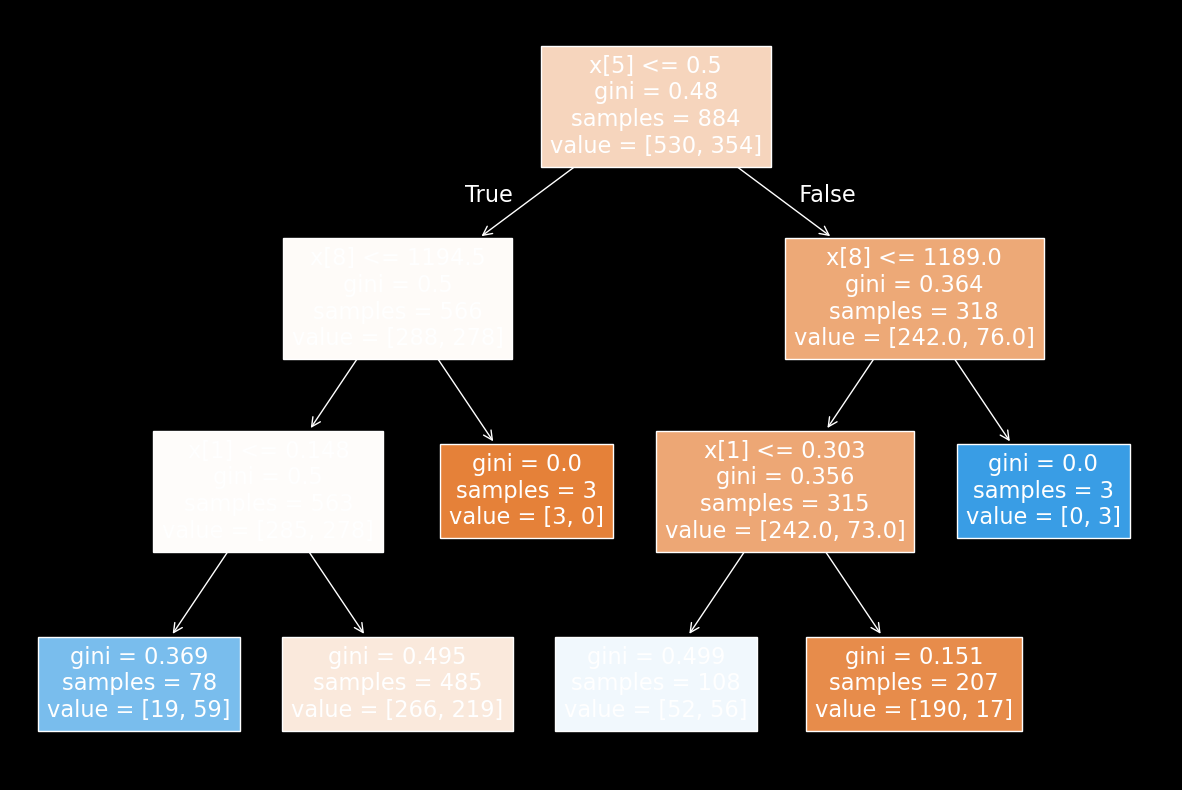

In [29]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=3,criterion='gini',splitter='best',min_samples_split=6,max_features=5,max_leaf_nodes=10)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

print(accuracy_score(y_test,y_pred))
confusion_matrix(y_test,y_pred)
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, filled=True)
plt.show()

In [35]:
from sklearn.ensemble import VotingClassifier,RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
x=data.drop(['Churn'],axis=1) 
y= data['Churn'].apply(ap)
x=ct.fit_transform(x)
estimators=[
    ('c1',LogisticRegression()),
    ('c2',SVC()),
    ('c3',DecisionTreeClassifier()),
    ('c4',RandomForestClassifier())
]



In [36]:
for estimator in estimators:
    scores = cross_val_score(estimator[1], x, y, cv=10, scoring='accuracy')
    print(estimator[0], np.round(np.mean(scores), 2))



c1 0.62
c2 0.61
c3 0.6
c4 0.63


In [37]:
vc=VotingClassifier(estimators=estimators , voting='hard')
p=cross_val_score(vc,x,y,scoring='accuracy')
print(np.round(np.mean(x),2))

66.78
